# Linear Regression: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **Linear Regression** in Python.

### Concept Overview
Models a linear relationship between input features and a continuous target.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon
$$

### Real-World Analogy
**Analogy:** Predicting a student's test score based on the number of hours they studied.

### Worked Example
**Worked Example:** Predicting salary from years of experience. With intercept beta_0 = 30000 and slope beta_1 = 9000, a person with 5 years experience is predicted to earn: 30000 + 9000 * 5 = $75,000.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of salary dataset
np.random.seed(42)
X_data = np.random.uniform(1.0, 10.5, 500)
noise = np.random.normal(0, 5000, 500)
y_data = 30000 + 9000 * X_data + noise
df = pd.DataFrame({
    'YearsExperience': np.round(X_data, 1),
    'Salary': np.round(y_data, 2)
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (500, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  500 non-null    float64
 1   Salary           500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB
       YearsExperience         Salary
count       500.000000     500.000000
mean          5.738400   81665.125660
std           2.836861   26364.389349
min           1.000000   31706.110000
25%           3.300000   58922.267500
50%           5.900000   82580.005000
75%           8.200000  104244.367500
max          10.400000  132554.560000


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 YearsExperience    0
Salary             0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We perform visual analysis of the dataset, examining correlation heatmaps and target-colored feature distributions to understand the underlying boundaries.

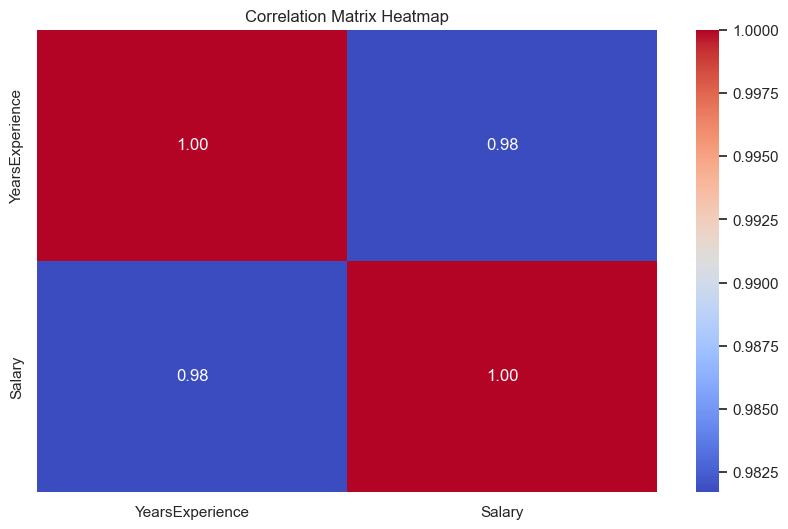

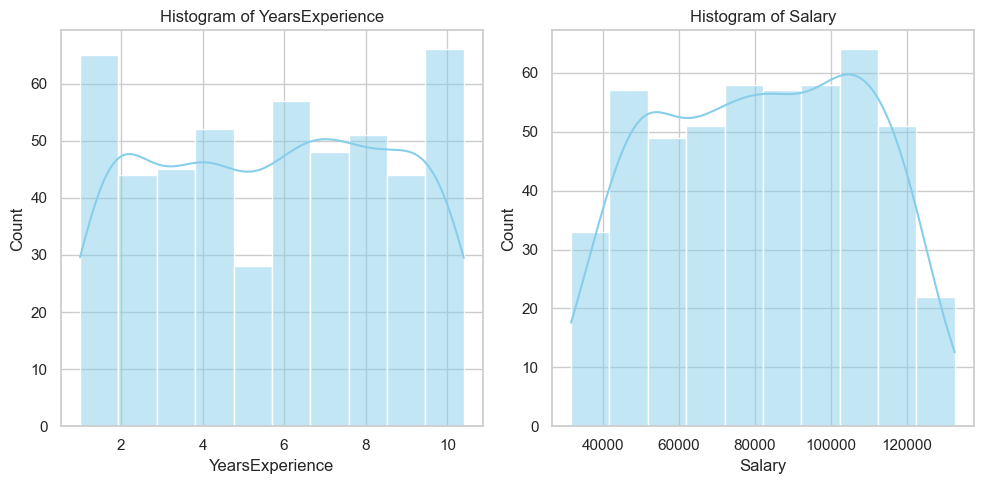

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Histograms of features and target
fig, axes = plt.subplots(1, len(df.columns), figsize=(5 * len(df.columns), 5))
if len(df.columns) == 1:
    sns.histplot(df.iloc[:, 0], kde=True, ax=axes, color='skyblue')
    axes.set_title(f'Histogram of {df.columns[0]}')
else:
    for idx, col in enumerate(df.columns):
        sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
        axes[idx].set_title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
print('Scaling not strictly needed for this model.')

Scaling not strictly needed for this model.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (350, 1), Test size: (150, 1)


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [9197.742597]
Intercept: 28965.174207705953


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
y_pred = model.predict(X_test)
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print("R2 Score:", metrics.r2_score(y_test, y_pred))

MAE: 4158.441482741098
MSE: 26063588.918626472
RMSE: 5105.251112200699
R2 Score: 0.9608930736738848


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

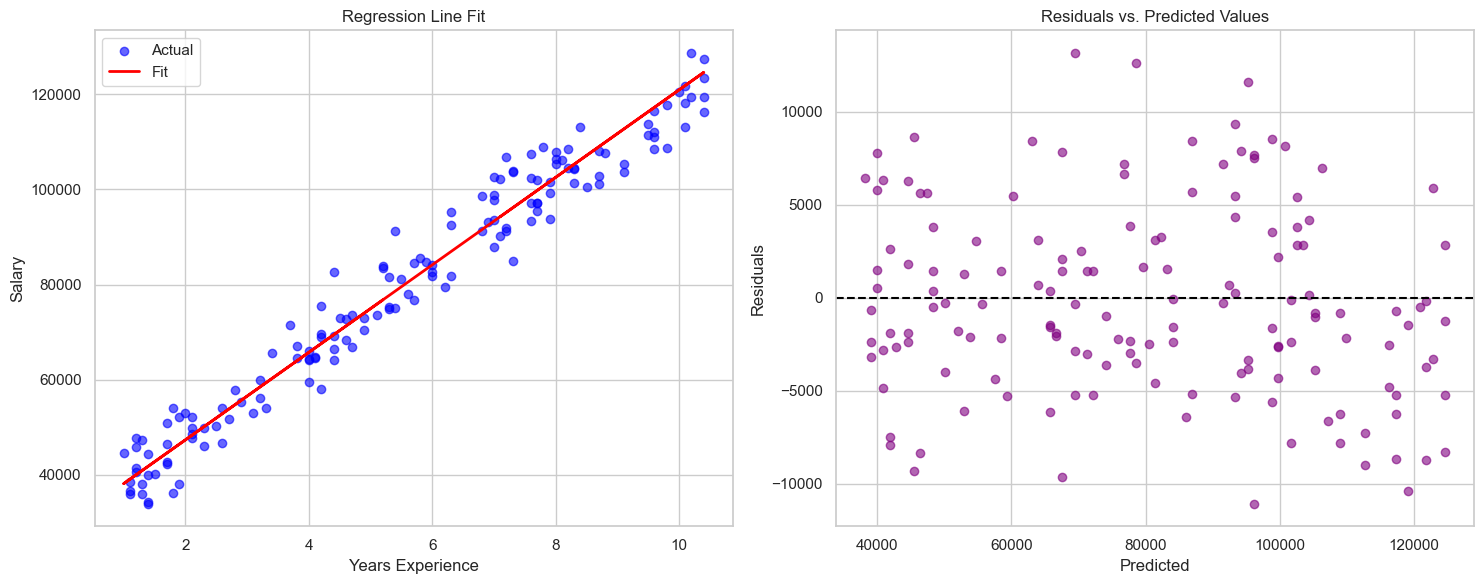

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot 1: Regression Line fit
axes[0].scatter(X_test, y_test, color='blue', alpha=0.6, label='Actual')
axes[0].plot(X_test, y_pred, color='red', linewidth=2, label='Fit')
axes[0].set_title("Regression Line Fit")
axes[0].set_xlabel("Years Experience")
axes[0].set_ylabel("Salary")
axes[0].legend()

# Plot 2: Residuals Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, color='purple', alpha=0.6)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title("Residuals vs. Predicted Values")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")
plt.tight_layout()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What is homoscedasticity?**

*A: Homoscedasticity means the residual variance is constant across all levels of independent variables. Heteroscedasticity violates OLS assumptions.*

**Q2: What are the 4 assumptions of OLS linear regression?**

*A: Linearity, Independence of errors, Homoscedasticity, and Normality of residual error distributions.*

**Q3: Why is R-squared not always the best metric?**

*A: R-squared always increases or stays same when features are added. Adjusted R-squared accounts for number of features and is preferred.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: Define residual.**

*A: The difference between the actual value and the predicted value: e = y - y_pred.*

**Q2: What value indicates a perfect fit for R2?**

*A: An R2 score of 1.0 indicates a perfect fit.*

**Q3: Does feature scaling change the R2 score?**

*A: No, scaling features changes coefficient scale but doesn't change the linear fit or R2 score.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.